In [36]:
import pandas as pd
import numpy as np

# 1. Load the dataset
# Ensure the CSV file is in the same directory as your script/notebook
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# 2. Initial data exploration
print("--- First 5 rows of the dataset ---")
display(df.head())

print("\n--- Column information and data types ---")
print(df.info())

# 3. Handle TotalCharges formatting issues
# This column is often loaded as 'object' due to empty spaces " ".
# Converting to numeric with errors='coerce' turns spaces into NaN.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# 4. Handle missing values (after conversion)
missing_values = df['TotalCharges'].isnull().sum()
print(f"\nMissing values in TotalCharges: {missing_values}")

# Dropping rows with missing TotalCharges as they represent a tiny fraction of the data
df.dropna(subset=['TotalCharges'], inplace=True)

# 5. Drop customerID column
# It's a unique identifier and doesn't provide predictive power for the model
df.drop('customerID', axis=1, inplace=True)

# 6. Summary statistics for numerical features
print("\n--- Descriptive Statistics ---")
display(df.describe())

# 7. Check target variable (Churn) balance
# This helps identify if the dataset is imbalanced
print("\n--- Churn Distribution (Percentage) ---")
print(df['Churn'].value_counts(normalize=True))

--- First 5 rows of the dataset ---


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



--- Column information and data types ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16 

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000



--- Churn Distribution (Percentage) ---
Churn
No     0.734215
Yes    0.265785
Name: proportion, dtype: float64


In [37]:
df_original = df.copy()

The Encoding Step because Model understand the data like convertt yes to 1 and No to 0


In [38]:
# 8. Encode Categorical Variables
# For Binary columns (Yes/No), we can use simple mapping or Label Encoding
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

# Also map 'gender' to 1 for Female and 0 for Male (or vice versa)
df['gender'] = df['gender'].map({'Female': 1, 'Male': 0})

# For multi-category columns (InternetService, Contract, PaymentMethod, etc.)
# We use "One-Hot Encoding" to create dummy variables
categorical_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity',
                    'OnlineBackup', 'DeviceProtection', 'TechSupport',
                    'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# 9. Final check of the preprocessed data
print("\n--- Final Data Shape and Columns ---")
print(df.shape)
display(df.head())


--- Final Data Shape and Columns ---
(7032, 31)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,False,False,False,True,False
1,0,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,False,False,False,True,False,False,False,True
2,0,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,False,False,False,True
3,0,0,0,0,45,0,0,42.30,1840.75,0,...,True,False,False,False,False,True,False,False,False,False
4,1,0,0,0,2,1,1,70.70,151.65,1,...,False,False,False,False,False,False,False,False,True,False


Visualize Churn across Demographics  هل صفات العميل الشخصية تؤثر على رحيله

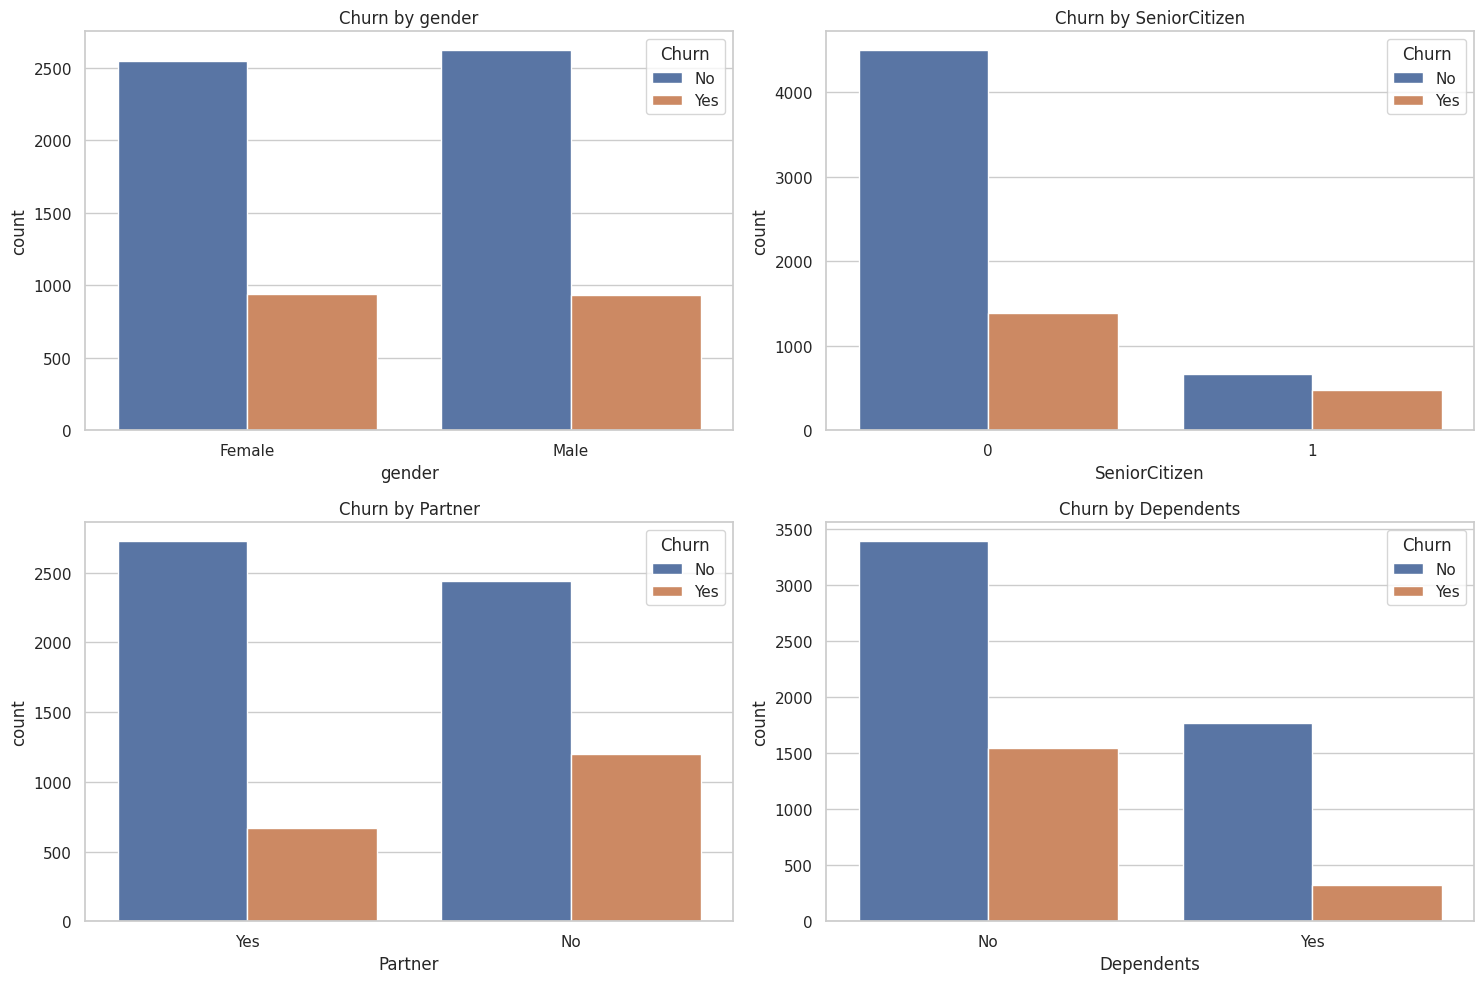

In [39]:
# 3. Now run the Visualization code:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
demo_features = ['gender', 'SeniorCitizen', 'Partner', 'Dependents']

plt.figure(figsize=(15, 10))
for i, feature in enumerate(demo_features, 1):
    plt.subplot(2, 2, i)
    # Now df_original exists!
    sns.countplot(data=df_original, x=feature, hue='Churn')
    plt.title(f'Churn by {feature}')

plt.tight_layout()
plt.show()

Churn vs. Services


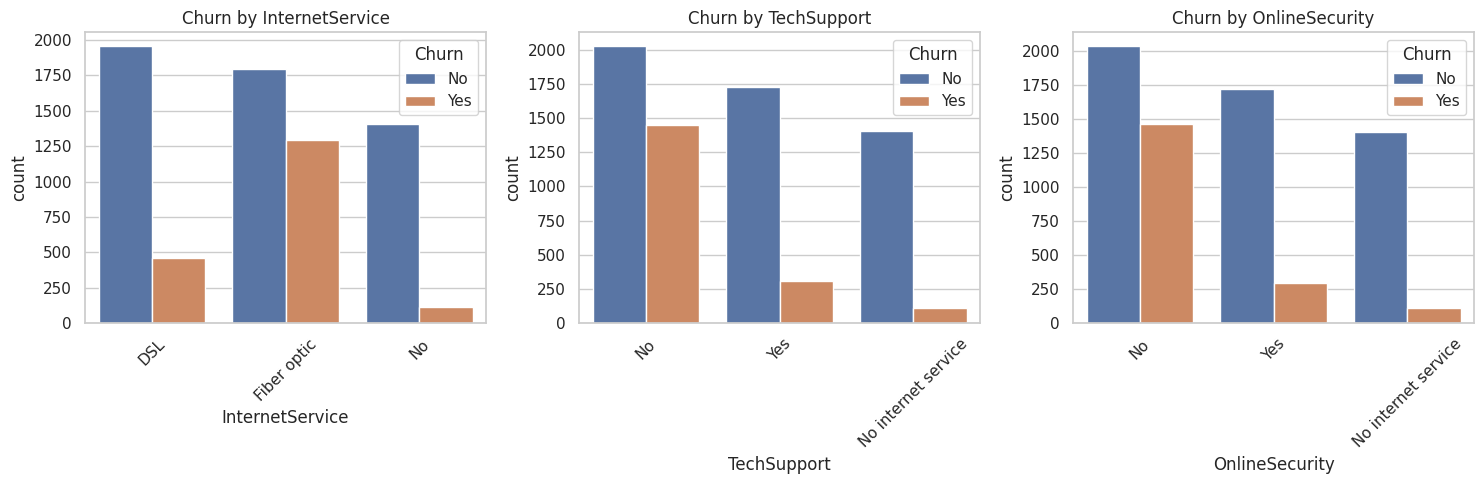

In [44]:
service_features = ['InternetService', 'TechSupport', 'OnlineSecurity']



plt.figure(figsize=(15, 5))

for i, feature in enumerate(service_features, 1):

    plt.subplot(1, 3, i)

    # This will now work because InternetService exists in df_original

    sns.countplot(data=df_original, x=feature, hue='Churn')

    plt.title(f'Churn by {feature}')

    plt.xticks(rotation=45)



plt.tight_layout()

plt.show()

Numerical Data (Tenure & Charges) & Contract Type

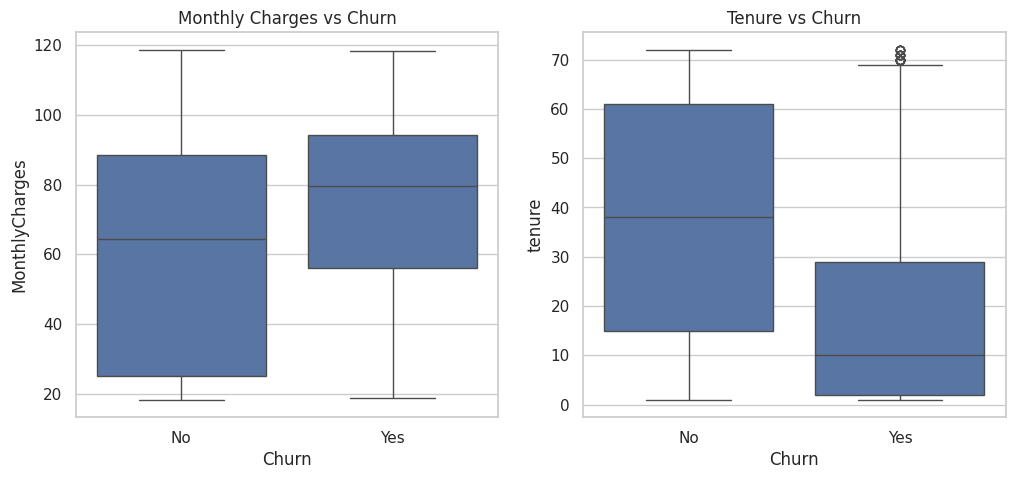

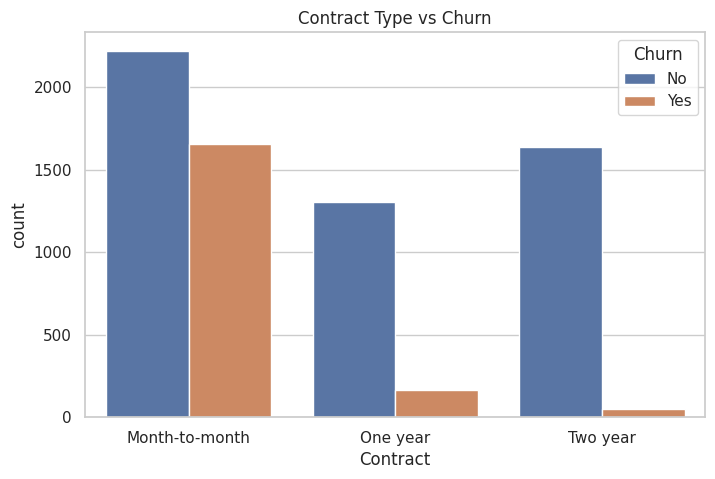

In [45]:
# Boxplot for Monthly Charges
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(data=df_original, x='Churn', y='MonthlyCharges')
plt.title('Monthly Charges vs Churn')

# Boxplot for Tenure
plt.subplot(1, 2, 2)
sns.boxplot(data=df_original, x='Churn', y='tenure')
plt.title('Tenure vs Churn')

plt.show()

# Bar chart for Contract Type
plt.figure(figsize=(8, 5))
sns.countplot(data=df_original, x='Contract', hue='Churn')
plt.title('Contract Type vs Churn')
plt.show()

Stratified Sampling

In [46]:
from sklearn.model_selection import train_test_split

# Define Features (X) and Target (y)
X = df.drop('Churn', axis=1)
y = df['Churn']

# Split: 80% Training, 20% Testing
# stratify=y ensures the 73/26 ratio is maintained in both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")

Training set size: (5625, 30)
Testing set size: (1407, 30)


In [47]:
print(df.dtypes.unique())
# يجب أن يطبع لكِ فقط [dtype('int64'), dtype('float64'), dtype('bool')]
# لو ظهر dtype('O') يعني لسه فيه نصوص!

[dtype('int64') dtype('float64') dtype('bool')]


تدريب الموديلات (Logistic Regression & Random Forest)

In [48]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc

# Model 1: Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

# Model 2: Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


RandomForestClassifier(random_state=42)

التقييم والمقارنة (Performance Metrics)

In [49]:
# Predictions
lr_preds = lr_model.predict(X_test)
rf_preds = rf_model.predict(X_test)

print("--- Logistic Regression Performance ---")
print(classification_report(y_test, lr_preds))

print("\n--- Random Forest Performance ---")
print(classification_report(y_test, rf_preds))

--- Logistic Regression Performance ---
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.64      0.57      0.60       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407


--- Random Forest Performance ---
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.63      0.50      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



الـ Visualization (Confusion Matrix & ROC Curve)
لرؤية الأخطاء (Type I & Type II Errors) بشكل مرئي.

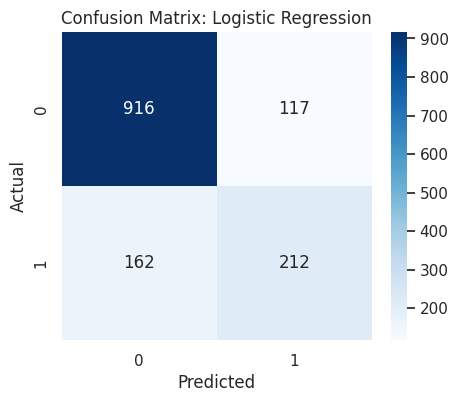

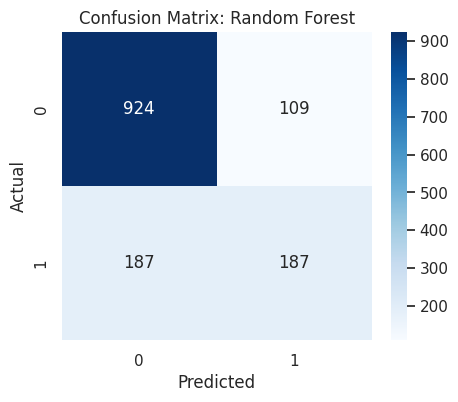

In [50]:
def plot_results(y_true, y_pred, model_name):
    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix: {model_name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

plot_results(y_test, lr_preds, "Logistic Regression")
plot_results(y_test, rf_preds, "Random Forest")

Feature Importance

In [51]:
importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

print("\n--- Top 5 Features ---")
print(feature_importance_df.head(5))


--- Top 5 Features ---
                           Feature  Importance
8                     TotalCharges    0.200809
4                           tenure    0.169570
7                   MonthlyCharges    0.167255
28  PaymentMethod_Electronic check    0.039211
11     InternetService_Fiber optic    0.037830


ROC Curve


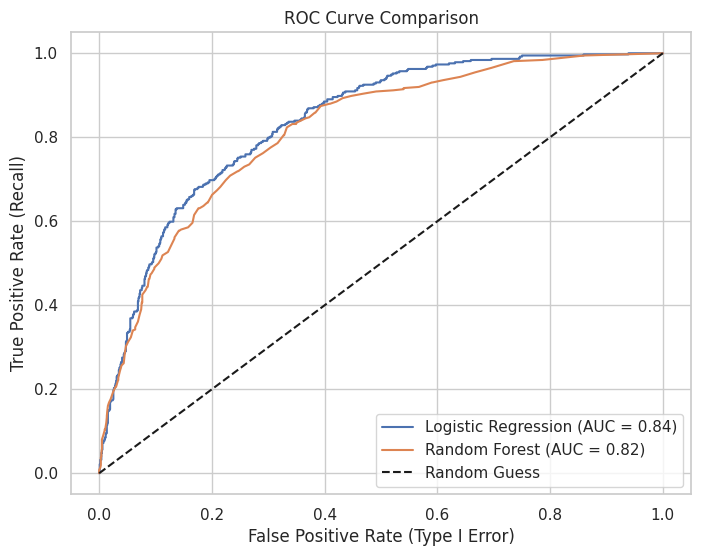

In [53]:
from sklearn.metrics import roc_curve, auc

lr_probs = lr_model.predict_proba(X_test)[:, 1]
rf_probs = rf_model.predict_proba(X_test)[:, 1]


lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)


lr_auc = auc(lr_fpr, lr_tpr)
rf_auc = auc(rf_fpr, rf_tpr)

plt.figure(figsize=(8, 6))
plt.plot(lr_fpr, lr_tpr, label=f'Logistic Regression (AUC = {lr_auc:.2f})')
plt.plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC = {rf_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')

plt.xlabel('False Positive Rate (Type I Error)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

In [54]:
import pandas as pd

# --- Step 1: Calculate Average Revenue Loss ---
# We use MonthlyCharges as the revenue metric
avg_monthly_revenue = df_original['MonthlyCharges'].mean()
total_churned = y_test[y_test == 1].shape[0]

# Estimate annual loss for the churned customers in our test set
annual_loss = total_churned * avg_monthly_revenue * 12
print(f"Total Churned Customers in Test Set: {total_churned}")
print(f"Estimated Annual Revenue Loss: ${annual_loss:,.2f}")

# --- Step 2: Simulate Retention Strategies ---
# Assumption: A retention campaign costs money but saves a percentage of customers
campaign_cost_per_customer = 20.0  # Cost of sending a discount/offer
retention_rate = 0.30              # We assume we can save 30% of those who were going to churn

saved_customers = int(total_churned * retention_rate)
revenue_saved = saved_customers * avg_monthly_revenue * 12
total_campaign_cost = total_churned * campaign_cost_per_customer
net_profit_from_campaign = revenue_saved - total_campaign_cost

print(f"\n--- Retention Strategy Simulation ---")
print(f"Customers Saved: {saved_customers}")
print(f"Revenue Saved: ${revenue_saved:,.2f}")
print(f"Campaign Investment: ${total_campaign_cost:,.2f}")
print(f"Net Profit/Loss from Strategy: ${net_profit_from_campaign:,.2f}")

# --- Step 3: Break-Even Analysis ---
# How many customers must we save to cover the campaign cost?
customers_to_break_even = total_campaign_cost / (avg_monthly_revenue * 12)
print(f"Break-even Point: Need to save at least {customers_to_break_even:.2f} customers.")

Total Churned Customers in Test Set: 374
Estimated Annual Revenue Loss: $290,814.36

--- Retention Strategy Simulation ---
Customers Saved: 112
Revenue Saved: $87,088.79
Campaign Investment: $7,480.00
Net Profit/Loss from Strategy: $79,608.79
Break-even Point: Need to save at least 9.62 customers.
